https://github.com/4GeeksAcademy/naive-bayes-project-tutorial/blob/main/solution.ipynb

In [34]:
import re
import numpy as np
import pandas as pd
import missingno as msno
from sklearn.feature_extraction.text import CountVectorizer #https://scikit-learn.org/stable/modules/feature_extraction.html#text-feature-extraction
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import BernoulliNB, MultinomialNB, ComplementNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from scipy.stats import uniform
from sklearn.model_selection import RandomizedSearchCV
import joblib
import warnings
warnings.filterwarnings('ignore')

In [4]:
def prob_bayes(modelo):
    ''' Aplica el Tª Bayes para hallar P(Y|X_i)
        - feature_log_prob=P(X_i|Y)
        - class_log_prior_=P(Y)'''
    p_tot_x_0=np.exp(modelo.feature_log_prob_[0])*np.exp(modelo.class_log_prior_[0])
    p_tot_x_1=np.exp(modelo.feature_log_prob_[1])*np.exp(modelo.class_log_prior_[1])
    p_bayes0=p_tot_x_0/(p_tot_x_0+p_tot_x_1)
    p_bayes1=p_tot_x_1/(p_tot_x_0+p_tot_x_1)
    return p_bayes0, p_bayes1

def opt_palabras(modelo, X_train, y_train, X_test, y_test):
    ''' Proceso de optimización de palabras'''
    #Calculamos diferencia frente a prob a priori
    diff_prob0=np.abs(prob_bayes(modelo)[0]-np.exp(modelo.class_log_prior_[0]))
    diff_prob1=np.abs(prob_bayes(modelo)[1]-np.exp(modelo.class_log_prior_[1]))
    #Creamos df con el nombre de las caract según su dif
    ## Poderamos para corregir desbalance
    diff_med=pd.Series(((np.exp(modelo.class_log_prior_[0])*diff_prob0)+(np.exp(modelo.class_log_prior_[1])*diff_prob1))/2, index=modelo.feature_names_in_)
    ##Guardamos palabras
    ord_col=diff_med.sort_values(ascending=True).index
    ##Listas para iterar col y agregar métricas
    ord_col_ascendente=[]
    metricas=[]
    #Eliminamos columnas de forma ascendente
    for col in ord_col[:-1]:
        ord_col_ascendente.append(col)
        X_prueba=X_train.drop(columns=ord_col_ascendente)
        X_exam=X_test.drop(columns=ord_col_ascendente)
        mod=MultinomialNB().fit(X_prueba, y_train)
        f1=f1_score(y_test, mod.predict(X_exam))
        pre=precision_score(y_test, mod.predict(X_exam))
        metricas.append([f1, pre])
    #Guardamos proceso para representar
    X_opt=pd.DataFrame(metricas, index=range(1, len(ord_col)), columns=['F1', 'Precision'])
    #Establecemos la cifra máxima de f1 y cálculamos el numero máximo de palabras que podemos eliminar
    pal_elm=X_opt[X_opt['F1']==X_opt["F1"].max()].index.max()
    #Graficamos
    plt.plot(X_opt["F1"], marker=',', label="F1 Score")
    plt.plot(X_opt["Precision"], marker=',',label="Precision")
    plt.plot(pal_elm, X_opt["F1"].max(), 'o', color="red")
    plt.title("evolución del acierto de las predicciones".upper(), fontweight='bold')
    plt.xlabel("Número de palabras eliminadas")
    plt.legend()
    plt.show()
    print("*"*50)
    print(f"Número de palabras a eliminar: {pal_elm}")
    #Eliminamos dichas columnas
    col_final=ord_col[:pal_elm]
    return X_train.drop(columns=col_final), X_test.drop(columns=col_final)

# **0. CONTEXTO Y CARGA DATOS**

[Fuente: https://github.com/4GeeksAcademy/random-forest-project-tutorial/blob/main/README.es.md](https://github.com/4GeeksAcademy/naive-bayes-project-tutorial/blob/main/README.es.md)

Descripción del proyecto:

Clasificar de reseñas de la tienda de Google Play.


Descripción de variables: 

- package_name. Nombre de la aplicación móvil (categórico)
- review. Comentario sobre la aplicación móvil (categórico)
- polarity. Variable de clase (0 o 1), siendo 0 un comentario negativo y 1, positivo (categórico numérico)

In [5]:
#Cargamos la base de datos en crudo
df=pd.read_csv("https://raw.githubusercontent.com/4GeeksAcademy/naive-bayes-project-tutorial/main/playstore_reviews.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   package_name  891 non-null    object
 1   review        891 non-null    object
 2   polarity      891 non-null    int64 
dtypes: int64(1), object(2)
memory usage: 21.0+ KB


In [6]:
df.head()

,package_name,review,polarity
0,com.facebook.katana,privacy at least put some option appear offli...,0
1,com.facebook.katana,"messenger issues ever since the last update, ...",0
2,com.facebook.katana,profile any time my wife or anybody has more ...,0
3,com.facebook.katana,the new features suck for those of us who don...,0
4,com.facebook.katana,forced reload on uploading pic on replying co...,0


In [7]:
# Eliminamos package_name
df.drop(columns="package_name", inplace=True)

# **1. PREPROCESAMIENTO DE DATOS**

## 1.1. Verificar valores

### 1.1.1. Unicos

In [ ]:
#Valores unicos por cada columna
unicos=df.nunique()
print("No hay columnas con valores únicos" if sum(unicos==1)==0 else "Hay columnas con valores únicos")

No hay columnas con valores únicos


### 1.1.2. Eliminación de filas y columnas duplicadas

In [9]:
#Indice
dup_fil=df.duplicated().sum()
print("No hay filas duplicadas" if dup_fil==0 else "Hay filas duplicadas")

No hay filas duplicadas


In [10]:
#Trasponemos las columnas para verificar que toda la fila (variable) no sea igual a otra
dup_col=df.T.duplicated(keep=False).sum()
print("No hay variables exactamente iguales" if dup_col==0 else "Hay variables exactamente iguales")

No hay variables exactamente iguales


## 1.2. Verificar missing values

In [11]:
# Columnas columnas con más de un 15% de valores faltantes
missing=df.isna().mean()*100
missing[missing>15]

Series([], dtype: float64)

<Axes: >

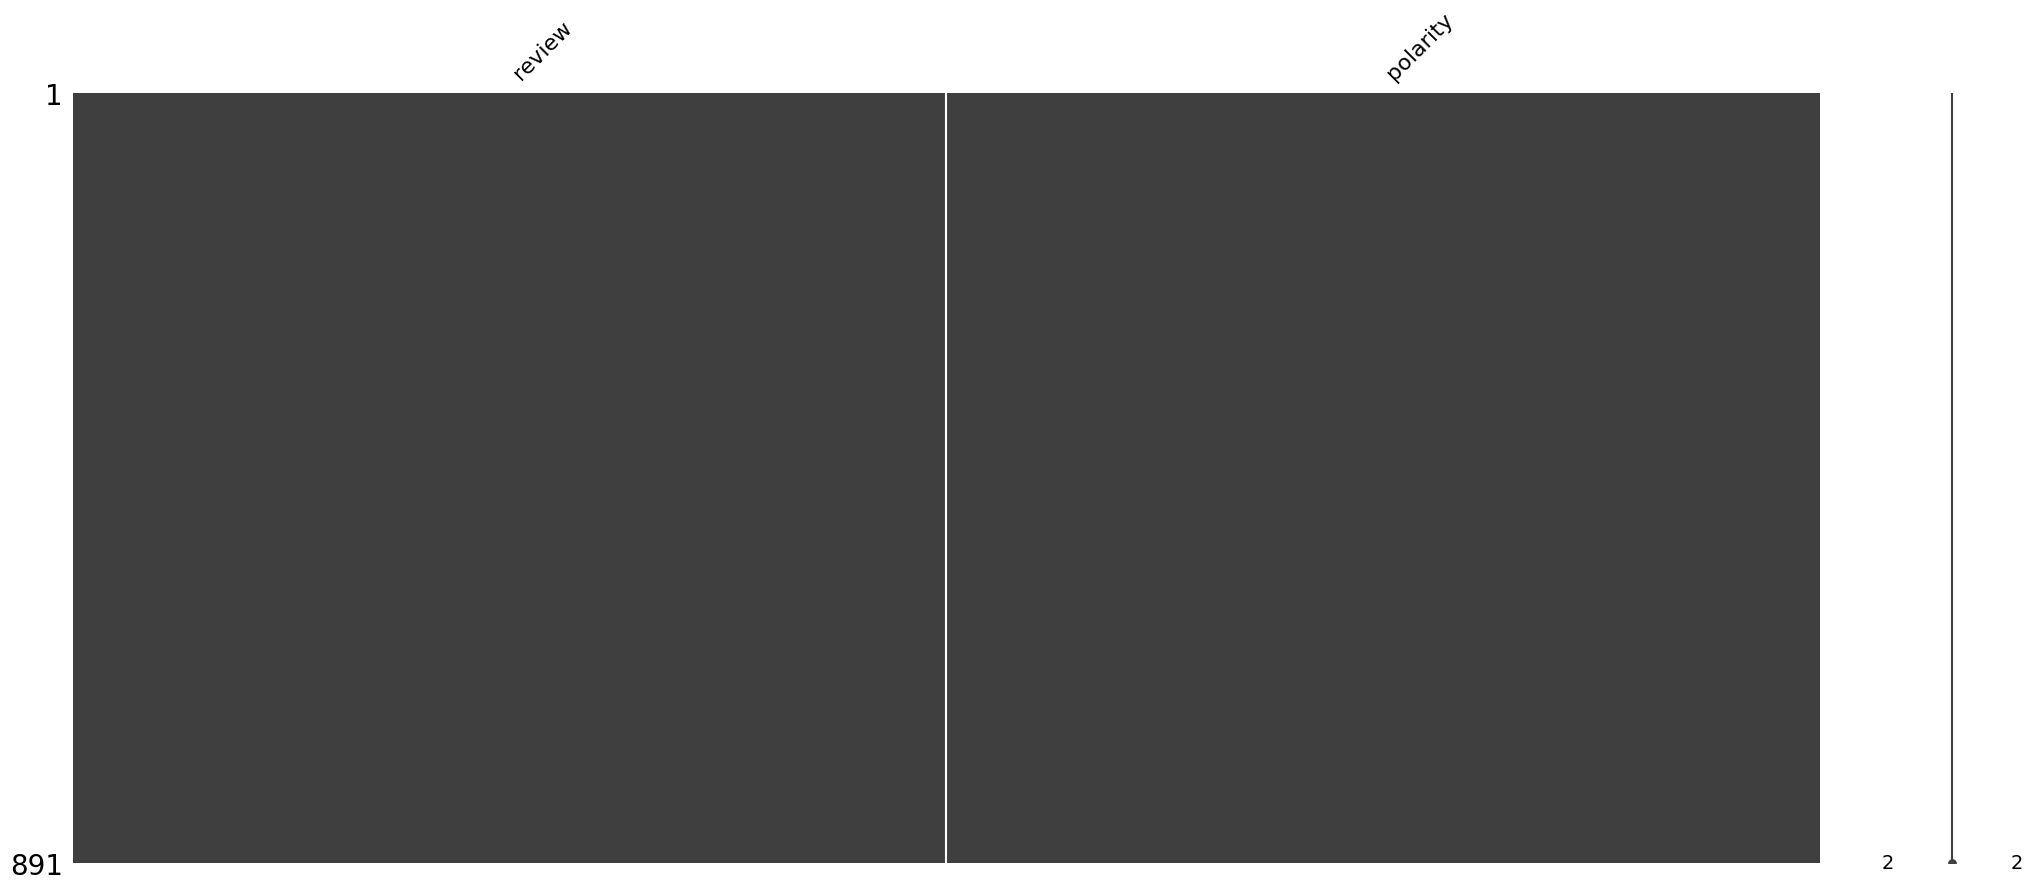

In [12]:
# Gráficamente
msno.matrix(df)

## 1.3. División Train-Test

In [13]:
# Definimos variables
##Strip: Limpiamos las columnas de espacios antes y depués del texto
##Lower: minúscula
X=df["review"].str.strip().str.lower()
y=df["polarity"]

# Dividimos los datos en conjuntos de entrenamiento y testeo
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 1.4. Vectorización ``review``

Esta variable contiene la reseña completa de la aplicación. En este caso, aplicaremos ``CountVectorizer()`` para extraer un conteo matricial por cada palabra observada en al menos una fila. Para aislar lo máximo posible la base de datos train, el conjuto de palabras posibles será definido en train a través de ``.fit()``

In [14]:
# CONFIGURACIÓN DEL VECTORIZADOR
## Función para eliminar letras repetidas dentro de uan palabra
def limpieza(text):
    """Elimina 3 o más repeticiones de una letra (ej. 'gooddd' -> 'good')."""
    text = re.sub(r'([a-zA-Z])\1{2,}', r'\1\1', text)
    return text

## Intanciamos el método
vectorizer=CountVectorizer(
    stop_words='english', #Elimina 'the', 'is', 'and', 'but', etc.
    token_pattern=r'\b[a-zA-Z]{2,}\b', #Limita a palabras de 3 o más letras
    preprocessor=limpieza, #Aplica la función anterior
    min_df=3, #Elimina palabras que solo aparecen en 1 o 2 veces (errores ortograficos)
    decode_error='ignore',  #Ignora caracteres que no se pueden decodificar (problemas de codificación)
    strip_accents='unicode') #Elimina signos de puntuacion (ej. 'é' a 'e')

In [15]:
# ENTRENAMOS Y APLICAMOS EN TRAIN
#Definimos conjunto de palabras posibles y aplicamos en train
vec = vectorizer.fit_transform(X_train)
# Configuramos como df
col=vectorizer.get_feature_names_out().tolist()
## Accedemos a los valores entrenados
X_train_vec=pd.DataFrame(vec.toarray(), ## Cargamos matriz vectorizada
                         columns=col, ## Cargamos columnas de la matriz
                         index=X_train.index) ## Mantenemos indice
X_train_vec.head(3)

,ability,able,access,account,accounts,action,active,actually,ad,add,...,writing,wrong,wtf,wth,xperia,year,years,yes,yo,youtube
331,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
733,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
382,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0


In [16]:
# ENTRENAMOS Y APLICAMOS EN TEST
#Definimos conjunto de palabras posibles y aplicamos en train
vec = vectorizer.transform(X_test)
# Configuramos como df
col=vectorizer.get_feature_names_out().tolist()
## Accedemos a los valores entrenados
X_test_vec=pd.DataFrame(vec.toarray(), ## Cargamos matriz vectorizada
                         columns=col, ## Cargamos columnas de la matriz
                         index=X_test.index) ## Mantenemos indice
X_test_vec.head(3)

,ability,able,access,account,accounts,action,active,actually,ad,add,...,writing,wrong,wtf,wth,xperia,year,years,yes,yo,youtube
709,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
439,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
840,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# **2. Entrenamiento**

## 2.1. Preevaluación 

In [17]:
y_train.value_counts(normalize=True)

polarity
0    0.643258
1    0.356742
Name: proportion, dtype: float64

In [18]:
for var in X_train_vec.columns:
    print(f"Palabra '{var}'")
    print(X_train_vec[var].value_counts())
    print("="*30)

Palabra 'ability'
ability
0    704
1      8
Name: count, dtype: int64
Palabra 'able'
able
0    677
1     32
2      3
Name: count, dtype: int64
Palabra 'access'
access
0    705
1      7
Name: count, dtype: int64
Palabra 'account'
account
0    698
1     12
2      2
Name: count, dtype: int64
Palabra 'accounts'
accounts
0    708
1      4
Name: count, dtype: int64
Palabra 'action'
action
0    709
1      2
2      1
Name: count, dtype: int64
Palabra 'active'
active
0    709
1      3
Name: count, dtype: int64
Palabra 'actually'
actually
0    703
1      9
Name: count, dtype: int64
Palabra 'ad'
ad
0    701
1     10
2      1
Name: count, dtype: int64
Palabra 'add'
add
0    684
1     26
2      1
3      1
Name: count, dtype: int64
Palabra 'added'
added
0    707
1      5
Name: count, dtype: int64
Palabra 'addictive'
addictive
0    707
1      5
Name: count, dtype: int64
Palabra 'adding'
adding
0    703
1      9
Name: count, dtype: int64
Palabra 'address'
address
0    707
1      4
2      1
Name: count

Una ves trabajada la base de datos, podemos resumir que nuestra base de datos se da siguiente forma:
- Nuestra variable a predecir $y_i$ es binaria (0=reseña negativa, 1=positiva) y esta desbalanceada (ver salida anterior)

- Nuestras variables predictoras $X_i$ representan un conteo el conjuto total justado de palabras del total de reseñas estudiadas.

De esta forma, tien un mayor sentido que las implementaciones de Naive Bayes a evaluar sean `MultinomialNB` (útil para clasificación de palabras) y `ComplementNB` (util para $y_i$ desbalanceada). No obstante, haremos un breve estudio inicial sobre qué implementación arroja un mayor f1 score.

In [19]:
#No estudiamos: GausianNB pues X_i no son continuas, CategoricalNB pues X_i son conteo no categorias
modelos=[BernoulliNB(), MultinomialNB(), ComplementNB()]
#Listas para almacenar las métricas: f1_score, recall
metricas=[]

#Recorremos cada modelo
for modelo in modelos:
    #Entrenamiento
    mod=modelo.fit(X_train_vec, y_train)
    #Evaluacion de la prediccion
    metricas.append([f1_score(y_test, mod.predict(X_test_vec)), 
                     recall_score(y_test, mod.predict(X_test_vec)),
                     precision_score(y_test, mod.predict(X_test_vec))])
    
#Mostramos el resultado
pd.DataFrame(metricas, columns=["F1 Score", "Sensibilidad", "Precision"], index=['BernoulliNB', 'MultinomialNB', 'ComplementNB']).round(5).sort_values(by="F1 Score", ascending=False)

,F1 Score,Sensibilidad,Precision
MultinomialNB,0.69565,0.75472,0.64516
BernoulliNB,0.68376,0.75472,0.62500
ComplementNB,0.67227,0.75472,0.60606


Podemos observar como la sensibilidad de todos los modelos es similar, mientras que el que mejores métricas arroja de F1 Score es `MultinomialNB`, por lo que será el que estudiaremos.

## 2.2. Entrenamiento

In [20]:
bayes = MultinomialNB().fit(X_train_vec, y_train)
y_pred = bayes.predict(X_test_vec)
#Metricas 
print(classification_report(y_test, y_pred)) #0: Train, 1: Test

              precision    recall  f1-score   support

           0       0.89      0.83      0.86       126
           1       0.65      0.75      0.70        53

    accuracy                           0.80       179
   macro avg       0.77      0.79      0.78       179
weighted avg       0.82      0.80      0.81       179



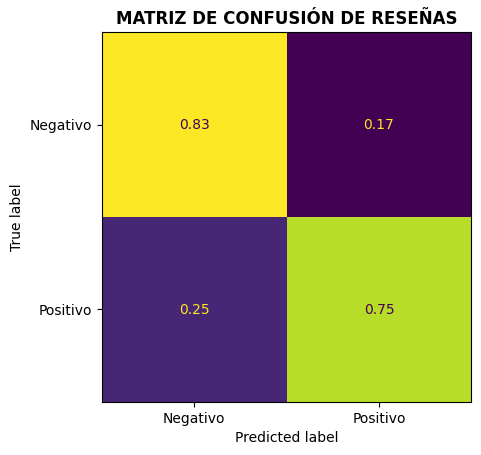

In [21]:
## Matriz de confusion
cm = confusion_matrix(y_test, bayes.predict(X_test_vec), labels=[0, 1], normalize="true")
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["Negativo", "Positivo"])
disp.plot(cmap="viridis", colorbar=False)
plt.title("Matriz de confusión de reseñas".upper(), fontweight="bold")
plt.show()

La fuerte caída en las métricas (0.1 de Accuracy, 0.2 de precision y 0.18 de F1) es un claro síntoma de sobreajuste (overfitting). Es decir, el modelo ha memorizado pratones existentes en train que no pueden ser replicados en test.

Además, el hecho de que el data set esté desbalanceado a favor de las reseñas negativas, tiene como efecto que el modelo clasifique mejora esta categoría (83% del total de negativas) e infraestima la cantidad de reseñas positivas (75% del total). Como consecuencia, el cantidad de reseñas clasificadas incorrectamente como negativas llegan a representar el 25% del total de postivas.

Para solucionarlo, ajustaremos el parámetro de suavizado y eliminaremos las palabras ruidosas.

## 2.3. Optimización

### A) Análisis de características

Vamos a proceder a localizar las palabras más ruidosas que no aporten información a la hora de discenir entre reseñas positivas y negativas, lo cual se traduce en que sus probabilidades bayesianas $P(Y|X_i)$ sean bastante cercanas a las probabilidades a priori $P(Y)$.


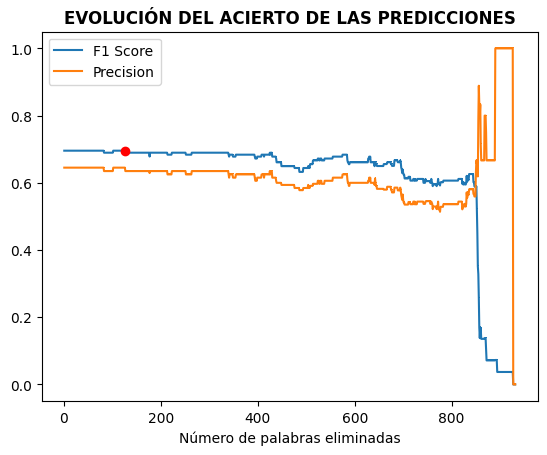

**************************************************
Número de palabras a eliminar: 126


In [22]:
X_train, X_test=opt_palabras(bayes, X_train_vec, y_train, X_test_vec, y_test)

### B) Análisis de suavizado

In [23]:
# Configurar RandomizedSearch
random_search = RandomizedSearchCV(
    estimator=MultinomialNB(),
    param_distributions={'alpha': uniform(1,10)},
    n_iter=30,
    scoring='recall',
    cv=5,
    verbose=2,
    n_jobs=-1,
    random_state=42,
)

# Ejecutamos la búsqueda 
random_search.fit(X_train_vec, y_train)
print("Mejores hiperparámetros:")
print(random_search.best_params_)
random_mod = random_search.best_estimator_ #Guardamos los resultados

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Mejores hiperparámetros:
{'alpha': np.float64(1.2058449429580245)}


In [24]:
##Predicciones
test_pred_opt = random_mod.predict(X_test_vec)
#Comparación de métricas
## Métricas
print("-"*60)
print("MODELO SIN OPTIMIZAR")
print("-"*60)
print(classification_report(y_test, y_pred))
## Métricas
print("-"*60)
print("MODELO OPTIMIZADO")
print("-"*60)
print(classification_report(y_test, test_pred_opt))

------------------------------------------------------------
MODELO SIN OPTIMIZAR
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.89      0.83      0.86       126
           1       0.65      0.75      0.70        53

    accuracy                           0.80       179
   macro avg       0.77      0.79      0.78       179
weighted avg       0.82      0.80      0.81       179

------------------------------------------------------------
MODELO OPTIMIZADO
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.89      0.82      0.85       126
           1       0.63      0.75      0.69        53

    accuracy                           0.80       179
   macro avg       0.76      0.79      0.77       179
weighted avg       0.81      0.80      0.80       179



[]

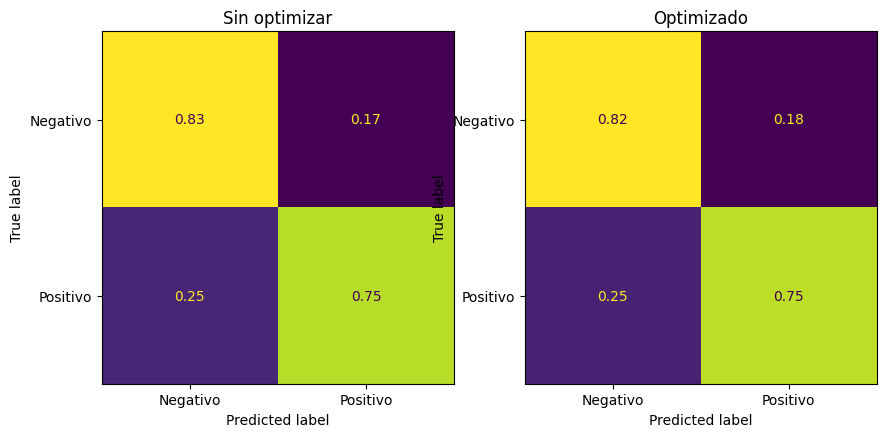

In [25]:
#Matriz de confusión
## Sin Optimizar
cm1 = confusion_matrix(y_test, y_pred, normalize='true')
## Optimizado
cm2 = confusion_matrix(y_test, test_pred_opt, normalize='true')

# Representación
fig, axis=plt.subplots(1,2, figsize=(10,5))
ConfusionMatrixDisplay(confusion_matrix=cm1, display_labels=["Negativo", "Positivo"]).plot(ax=axis[0],cmap='viridis',colorbar=False)
axis[0].set_title("Sin optimizar")
ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=["Negativo", "Positivo"]).plot(ax=axis[1],cmap='viridis', colorbar=False)
axis[1].set_title("Optimizado")
plt.plot()

Pese a haber eliminado las palabras con menor influencia sobre las predicciones, las preciones del modelo parecen no verse alteradas significativamente, por lo que seleccionaremos el más sencillo.

In [ ]:
#Exportamos el modelo con joblib (más rápido que pickle)
joblib.dump(random_mod, "07-NB.joblib")

['NB.joblib']

### C) Regresión logistica regularizada

Como tenemosun elevado numero de palabras candidatas para estudiar la calidad de la reseña, entrenaremos un modelo logit con regularización l1 para forzar a 0 las palabras menos útiles.

In [35]:
log_reg = LogisticRegression(penalty='l1', solver='liblinear', C=1.0, random_state=42)
log_reg.fit(X_train_vec, y_train)

LogisticRegression(penalty='l1', random_state=42, solver='liblinear')

[]

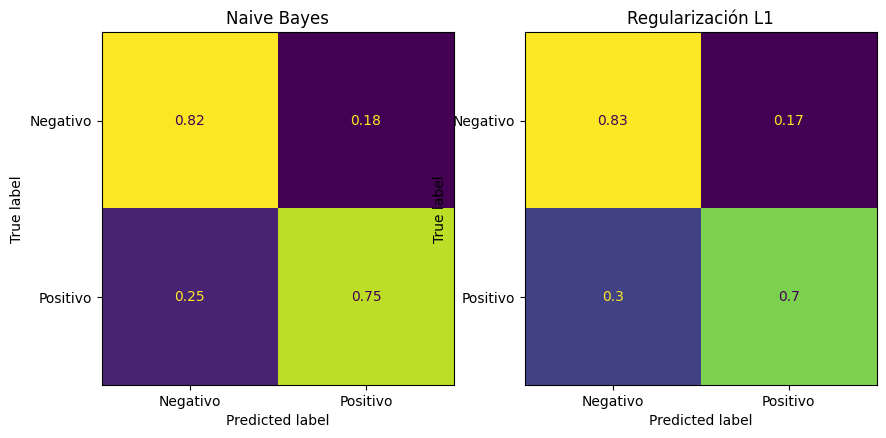

In [36]:
#Matriz de confusión
## Naive Bayes
cm1 = confusion_matrix(y_test, test_pred_opt, normalize='true')
## Optimizado
cm2 = confusion_matrix(y_test,log_reg.predict(X_test_vec), normalize='true')

# Representación
fig, axis=plt.subplots(1,2, figsize=(10,5))
ConfusionMatrixDisplay(confusion_matrix=cm1, display_labels=["Negativo", "Positivo"]).plot(ax=axis[0],cmap='viridis',colorbar=False)
axis[0].set_title("Naive Bayes")
ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=["Negativo", "Positivo"]).plot(ax=axis[1],cmap='viridis', colorbar=False)
axis[1].set_title("Regularización L1")
plt.plot()

Pese a aplicar el modelo de regresión logistica regularizado para trabajar con un elevado numero de regresores, la predicciones observadas son peores de las que teníamos con el modelo NaiveBayes, lo cual valida el uso del modelo anterior.